# Geometric Brownian Motion and Derivative Pricing
### A Theoretical Foundation — Implementation Notebook
**Aakash Agarwal**

---
This notebook is the computational companion to the theory document. Each section maps directly to the PDF. The goal is not a production pipeline — it is to make every major theoretical result visible and verifiable in code.


## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


---
## 1 — Log-Price and the Log-Normal Distribution


### 1.1 Multiplicative vs Additive Returns

Prices evolve multiplicatively. A +10% move followed by a -10% move does not return to the starting price — it leaves you at 99, not 100. The asymmetry arises because percentage moves are applied to a changing base. The log transformation converts this product structure into a sum, making standard statistical tools applicable.


In [2]:
S0 = 100.0

# Multiplicative: +10% then -10%
S1_mult = S0 * 1.10          # after +10%
S2_mult = S1_mult * 0.90     # after -10%

# Additive assumption (wrong): +10 then -10
S2_add = S0 + 10 - 10

print(f"Start:                        {S0:.2f}")
print(f"After +10%:                   {S1_mult:.2f}")
print(f"After +10% then -10%:         {S2_mult:.2f}  (not 100)")
print(f"Additive assumption gives:    {S2_add:.2f}")
print(f"Loss from multiplicative:     {S2_mult - S0:.2f}")
print()
print("Why? -10% applied to 110, not 100. The base changed.")
print(f"To recover 100 from 110 requires: {(100/110 - 1)*100:.4f}%, not -10%")


Start:                        100.00
After +10%:                   110.00
After +10% then -10%:         99.00  (not 100)
Additive assumption gives:    100.00
Loss from multiplicative:     -1.00

Why? -10% applied to 110, not 100. The base changed.
To recover 100 from 110 requires: -9.0909%, not -10%


### 1.2 Log-Returns Are Additive

Taking logs converts the product of growth factors into a sum — making the Central Limit Theorem applicable to the terminal log-price.


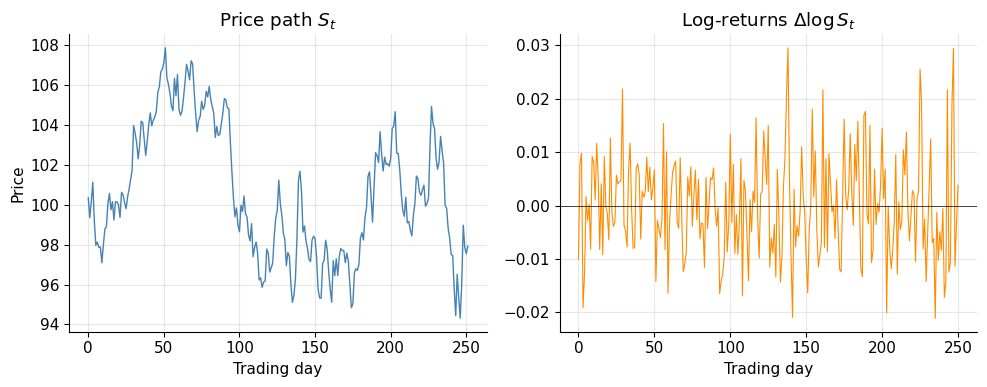

In [3]:
n_periods   = 252
mu_daily    = 0.0004
sigma_daily = 0.01

shocks      = rng.normal(mu_daily, sigma_daily, n_periods)
price_path  = S0 * np.exp(np.cumsum(shocks))
log_returns = np.diff(np.log(price_path))

fig, axes = plt.subplots(1, 2)
axes[0].plot(price_path, color='steelblue', lw=1)
axes[0].set_title('Price path $S_t$')
axes[0].set_xlabel('Trading day')
axes[0].set_ylabel('Price')

axes[1].plot(log_returns, color='darkorange', lw=0.8)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title(r'Log-returns $\Delta \log S_t$')
axes[1].set_xlabel('Trading day')

plt.tight_layout()
plt.show()


### 1.3 Log-Price Is Normally Distributed — Price Is Log-Normal

These are the same statement in two different spaces. $\log S_T \sim \mathcal{N}$ is the view in log-space; $S_T$ log-normal is the view in price-space. Exponentiating one gives the other — this is why the distribution is called **log-normal**: the *log* of the variable is *normal*.


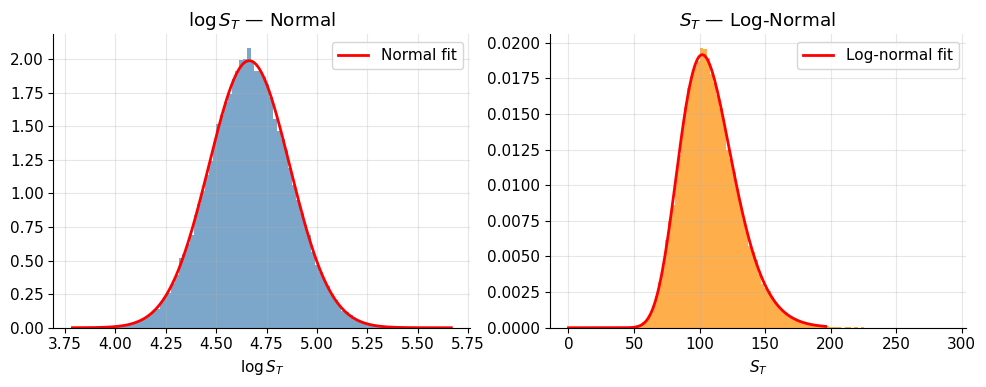

E[S_T] theoretical: 108.3287
E[S_T] simulated:   108.2548


In [4]:
T     = 1.0
mu    = 0.08
sigma = 0.20
N     = 100_000

W_T     = rng.normal(0, np.sqrt(T), N)
log_S_T = np.log(S0) + (mu - 0.5*sigma**2)*T + sigma*W_T
S_T     = np.exp(log_S_T)

fig, axes = plt.subplots(1, 2)

# Log-price: normal
axes[0].hist(log_S_T, bins=100, density=True, color='steelblue', alpha=0.7)
x = np.linspace(log_S_T.min(), log_S_T.max(), 300)
axes[0].plot(x, norm.pdf(x, log_S_T.mean(), log_S_T.std()), 'r-', lw=2, label='Normal fit')
axes[0].set_title(r'$\log S_T$ — Normal')
axes[0].set_xlabel(r'$\log S_T$')
axes[0].legend()

# Price: log-normal
axes[1].hist(S_T, bins=100, density=True, color='darkorange', alpha=0.7)
x2    = np.linspace(0, S_T.mean() + 4*S_T.std(), 300)
scale = np.exp(np.log(S0) + (mu - 0.5*sigma**2)*T)
axes[1].plot(x2, lognorm.pdf(x2, s=sigma*np.sqrt(T), scale=scale), 'r-', lw=2, label='Log-normal fit')
axes[1].set_title(r'$S_T$ — Log-Normal')
axes[1].set_xlabel(r'$S_T$')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"E[S_T] theoretical: {S0 * np.exp(mu*T):.4f}")
print(f"E[S_T] simulated:   {S_T.mean():.4f}")


---
## 2 — Linearization via Logarithm


### 2.1 The Itô Correction

The log transformation introduces a $-\frac{1}{2}\sigma^2$ correction. This is not optional — omitting it inflates the expected price. Below we verify numerically that $\mathbb{E}[S_T] = S_0 e^{\mu T}$ holds only with the correction.


In [5]:
N     = 200_000
W_T   = rng.normal(0, np.sqrt(T), N)

S_with    = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*W_T)   # correct
S_without = S0 * np.exp(mu*T + sigma*W_T)                     # missing Ito correction
theoretical = S0 * np.exp(mu*T)

print(f"Theoretical  E[S_T] = S0 * exp(mu*T):  {theoretical:.4f}")
print(f"With    Ito correction — E[S_T]:        {S_with.mean():.4f}")
print(f"Without Ito correction — E[S_T]:        {S_without.mean():.4f}")
print(f"Inflation without correction:           {S_without.mean() - theoretical:.4f}")


Theoretical  E[S_T] = S0 * exp(mu*T):  108.3287
With    Ito correction — E[S_T]:        108.3774
Without Ito correction — E[S_T]:        110.5668
Inflation without correction:           2.2381


### 2.2 The Integration Step

A differential $d(\log S)$ is an infinitesimal — it describes instantaneous dynamics but gives no information about total displacement over a finite interval $[0, T]$. To recover $\log S_T - \log S_0$ we integrate both sides. With constant coefficients the integral closes exactly.

The plot below shows five simulated $\log S_t$ paths built by numerically integrating $d(\log S)$ step by step. Each path accumulates the constant drift $(\mu - \frac{\sigma^2}{2})t$ plus a Brownian noise term. The dashed line is the pure drift component with no noise — the expected trajectory in log-space. Paths spread around it due to the $\sigma\,dW$ term, but all are anchored to the same linear drift. This is exactly what the closed-form integral solution says: $\log S_T = \log S_0 + (\mu - \frac{\sigma^2}{2})T + \sigma W_T$.


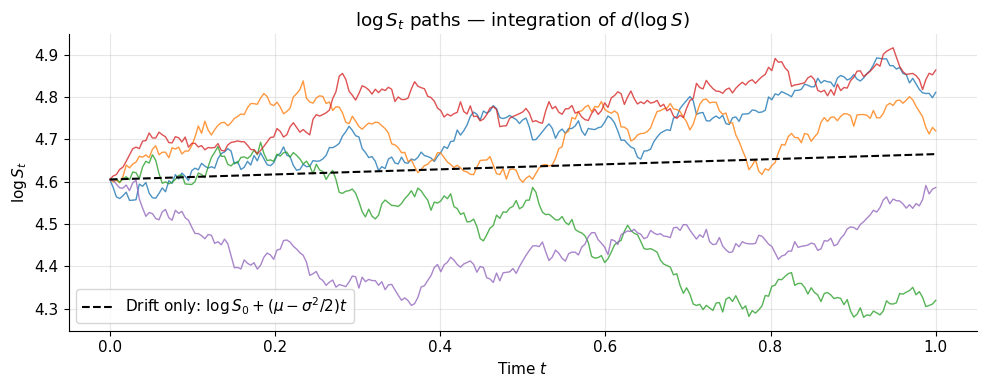

In [6]:
dt      = 1/252
steps   = int(T/dt)
n_paths = 5

log_S = np.zeros((n_paths, steps+1))
log_S[:, 0] = np.log(S0)

dW = rng.normal(0, np.sqrt(dt), (n_paths, steps))
for t in range(steps):
    log_S[:, t+1] = log_S[:, t] + (mu - 0.5*sigma**2)*dt + sigma*dW[:, t]

t_grid  = np.linspace(0, T, steps+1)
drift   = np.log(S0) + (mu - 0.5*sigma**2)*t_grid

plt.figure()
for i in range(n_paths):
    plt.plot(t_grid, log_S[i], lw=1, alpha=0.8)
plt.plot(t_grid, drift, 'k--', lw=1.5, label=r'Drift only: $\log S_0 + (\mu - \sigma^2/2)t$')
plt.title(r'$\log S_t$ paths — integration of $d(\log S)$')
plt.xlabel('Time $t$')
plt.ylabel(r'$\log S_t$')
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 Scaling Back

We exponentiate back to price-space because prices are what we observe and trade. The log-space analysis was purely for mathematical tractability. Applying $S = e^X$ recovers the price path and confirms the log-normal shape of $S_T$.


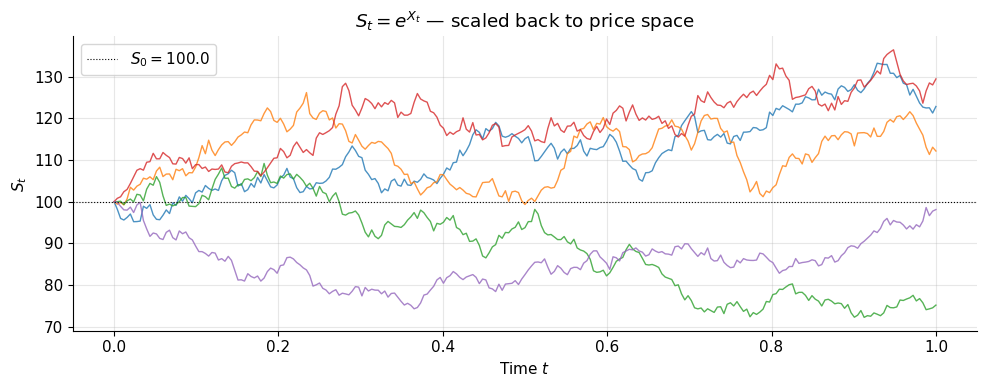

In [7]:
S_paths = np.exp(log_S)

plt.figure()
for i in range(n_paths):
    plt.plot(t_grid, S_paths[i], lw=1, alpha=0.8)
plt.axhline(S0, color='black', lw=0.8, ls=':', label=f'$S_0 = {S0}$')
plt.title(r'$S_t = e^{X_t}$ — scaled back to price space')
plt.xlabel('Time $t$')
plt.ylabel(r'$S_t$')
plt.legend()
plt.tight_layout()
plt.show()


---
## 3 — GBM Formulation


### 3.1 Discrete Hypothesis: Log-Returns Are i.i.d. Normal

GBM assumes log-returns are independent and identically distributed. The sum of $n$ such returns converges to $\mathcal{N}(\mu T, \sigma^2 T)$ by the Central Limit Theorem. We verify this holds.


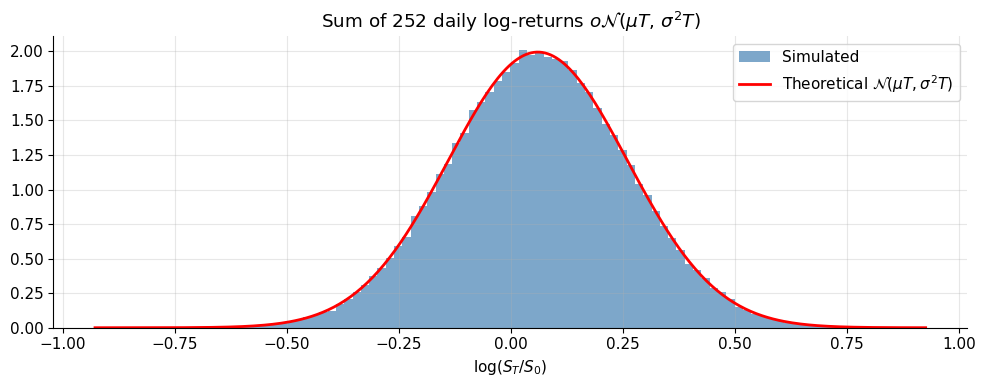

Theoretical mean: 0.0600  |  Simulated: 0.0604
Theoretical std:  0.2000  |  Simulated: 0.1999


In [8]:
log_returns_sim    = (mu - 0.5*sigma**2)/252 + sigma*rng.normal(0, np.sqrt(1/252), (N, 252))
terminal_log_return = log_returns_sim.sum(axis=1)

theoretical_mean = (mu - 0.5*sigma**2)*T
theoretical_std  = sigma*np.sqrt(T)

plt.figure()
plt.hist(terminal_log_return, bins=100, density=True, color='steelblue', alpha=0.7, label='Simulated')
x = np.linspace(terminal_log_return.min(), terminal_log_return.max(), 300)
plt.plot(x, norm.pdf(x, theoretical_mean, theoretical_std), 'r-', lw=2,
         label=r'Theoretical $\mathcal{N}(\mu T, \sigma^2 T)$')
plt.title(r'Sum of 252 daily log-returns $	o \mathcal{N}(\mu T,\, \sigma^2 T)$')
plt.xlabel(r'$\log(S_T / S_0)$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical mean: {theoretical_mean:.4f}  |  Simulated: {terminal_log_return.mean():.4f}")
print(f"Theoretical std:  {theoretical_std:.4f}  |  Simulated: {terminal_log_return.std():.4f}")


### 3.2 Discrete to Continuous Convergence

The GBM hypothesis starts discrete: at each step $\Delta t$, price moves by a random log-return. As $\Delta t \to 0$ the steps become infinitesimally small and the discrete sum of log-returns becomes a stochastic integral against Brownian motion --- this is the continuous SDE.

The chart makes this concrete. Monthly steps give a path that can only change direction 12 times --- visibly coarse. Weekly gives 52. Daily gives 252, smooth enough to serve as the practical continuous limit. The continuous SDE is the mathematical object that sits at this limit: drift and diffusion are now defined at every instant, and $dW_t$ replaces $\varepsilon\sqrt{\Delta t}$ as the infinitesimal Brownian increment. Everything derived in Section 4 onward operates in this continuous limit.


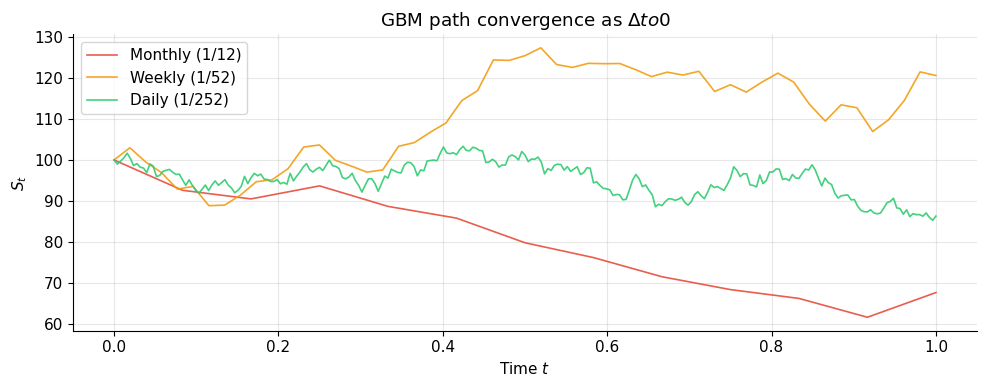

In [9]:
step_sizes = [1/12, 1/52, 1/252]
labels     = ['Monthly (1/12)', 'Weekly (1/52)', 'Daily (1/252)']
colors     = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure()
for dt_val, label, color in zip(step_sizes, labels, colors):
    n_steps = int(T / dt_val)
    path    = np.zeros(n_steps + 1)
    path[0] = S0
    dW_val  = rng.normal(0, np.sqrt(dt_val), n_steps)
    for t in range(n_steps):
        path[t+1] = path[t] * np.exp((mu - 0.5*sigma**2)*dt_val + sigma*dW_val[t])
    plt.plot(np.linspace(0, T, n_steps+1), path, lw=1.2, label=label, color=color, alpha=0.9)

plt.title(r'GBM path convergence as $\Delta t 	o 0$')
plt.xlabel('Time $t$')
plt.ylabel('$S_t$')
plt.legend()
plt.tight_layout()
plt.show()


---
## 4 — GBM SDE: Derivation and Pricing


### 4.1 Simulated Terminal Distribution

The closed-form solution $S_T = S_0 \exp\!\left((\mu - \frac{\sigma^2}{2})T + \sigma W_T\right)$ gives the full distribution of terminal prices directly — no path simulation needed. Mean and median diverge because the log-normal is right-skewed.


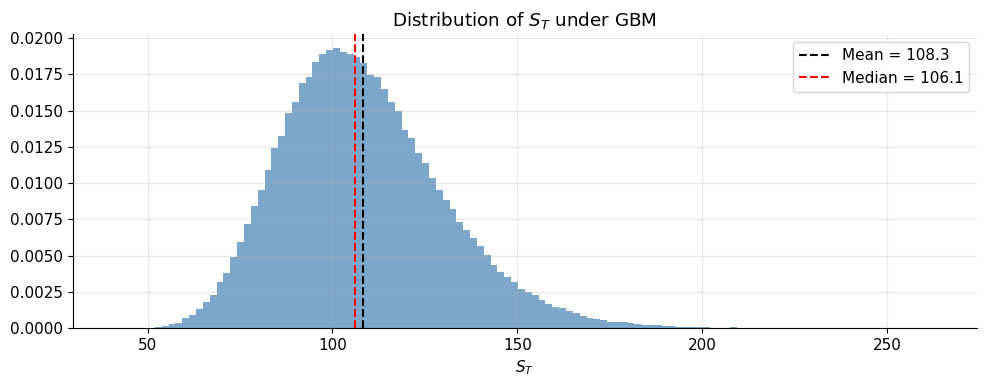

Theoretical mean:   108.3287
Simulated mean:     108.2936
Theoretical median: 106.1837
Simulated median:   106.1172


In [10]:
S_T_sim = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*rng.normal(0, np.sqrt(T), N))

plt.figure()
plt.hist(S_T_sim, bins=120, density=True, color='steelblue', alpha=0.7)
plt.axvline(S_T_sim.mean(),      color='black', lw=1.5, ls='--', label=f'Mean = {S_T_sim.mean():.1f}')
plt.axvline(np.median(S_T_sim),  color='red',   lw=1.5, ls='--', label=f'Median = {np.median(S_T_sim):.1f}')
plt.title('Distribution of $S_T$ under GBM')
plt.xlabel('$S_T$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical mean:   {S0 * np.exp(mu*T):.4f}")
print(f"Simulated mean:     {S_T_sim.mean():.4f}")
print(f"Theoretical median: {S0 * np.exp((mu - 0.5*sigma**2)*T):.4f}")
print(f"Simulated median:   {np.median(S_T_sim):.4f}")


### 4.2 European Call — Two Routes, One Answer

This is a general principle: for any derivative written on any stochastic underlying, there are always two routes to the pricing formula. The **expectation route** computes $e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{payoff}]$ using the distribution of the underlying under the risk-neutral measure. The **PDE route** applies Itô's lemma to $V$, constructs a riskless hedge portfolio, and imposes no-arbitrage as a boundary value problem. Both routes always produce the same answer. For GBM with a European payoff both are tractable — for more complex SDEs or payoffs, one route is typically far simpler than the other.

Below we verify numerically: the risk-neutral Monte Carlo expectation and the closed-form BS formula (derived via the PDE route in the companion document) must agree exactly.


In [11]:
def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

S0_p, K, r, sigma_p, T_p = 100, 100, 0.05, 0.20, 1.0

# Route 1: risk-neutral Monte Carlo
W_Q      = rng.normal(0, np.sqrt(T_p), 500_000)
S_T_Q    = S0_p * np.exp((r - 0.5*sigma_p**2)*T_p + sigma_p*W_Q)
mc_price = np.exp(-r*T_p) * np.maximum(S_T_Q - K, 0).mean()

# Route 2: closed-form BS
bs_price = bs_call(S0_p, K, r, sigma_p, T_p)

print(f"Monte Carlo (risk-neutral expectation): {mc_price:.4f}")
print(f"Black-Scholes closed form:              {bs_price:.4f}")
print(f"Difference:                             {abs(mc_price - bs_price):.4f}")


Monte Carlo (risk-neutral expectation): 10.4686
Black-Scholes closed form:              10.4506
Difference:                             0.0180


### 4.3 BS Price Across Strikes

The BS formula prices the full range of strikes under GBM — constant volatility, symmetric in log-space. The price approaches intrinsic value deep in-the-money and decays to zero deep out-of-the-money.


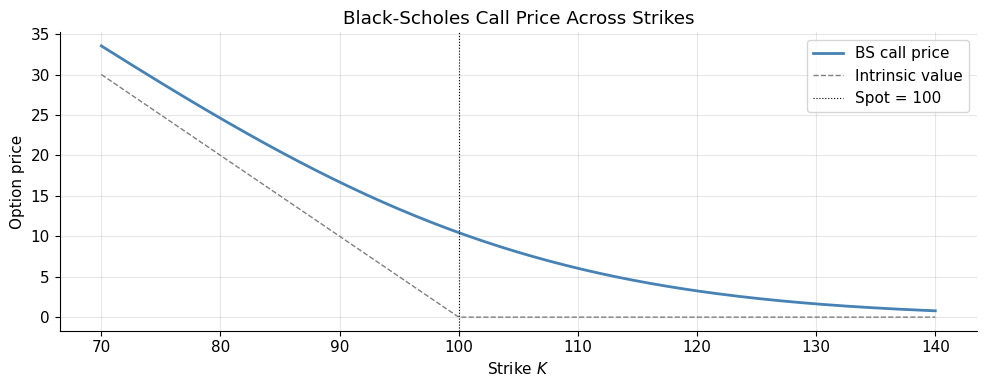

In [12]:
strikes   = np.linspace(70, 140, 200)
prices    = [bs_call(S0_p, K_i, r, sigma_p, T_p) for K_i in strikes]
intrinsic = np.maximum(S0_p - strikes, 0)

plt.figure()
plt.plot(strikes, prices,    color='steelblue', lw=2,  label='BS call price')
plt.plot(strikes, intrinsic, color='grey',      lw=1,  ls='--', label='Intrinsic value')
plt.axvline(S0_p, color='black', lw=0.8, ls=':', label=f'Spot = {S0_p}')
plt.title('Black-Scholes Call Price Across Strikes')
plt.xlabel('Strike $K$')
plt.ylabel('Option price')
plt.legend()
plt.tight_layout()
plt.show()


---
## 5 — The Black-Scholes PDE


### 5.1 $V(S, t)$ at Different Times to Expiry

The BS PDE solution $V(S,t)$ varies with both the asset price $S$ and remaining time $\tau = T - t$. As $\tau \to 0$ the solution collapses onto the terminal payoff. The curves below show how time value erodes as expiry approaches.


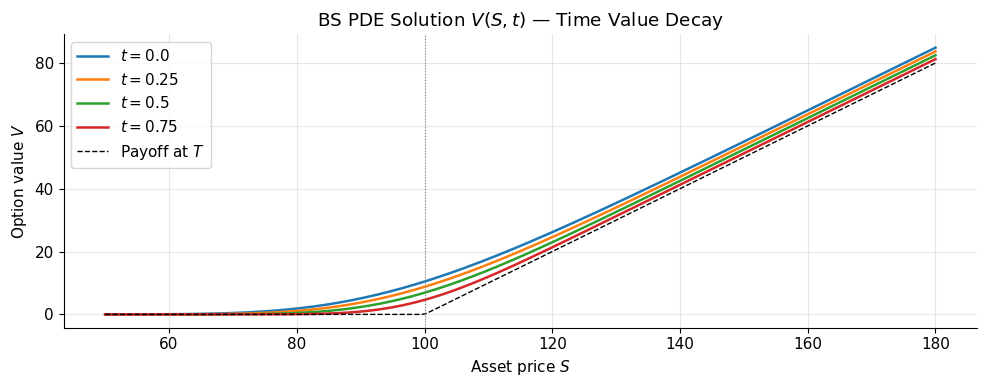

In [13]:
S_grid = np.linspace(50, 180, 200)
t_vals = [0.0, 0.25, 0.50, 0.75]
K_pde, r_pde, sigma_pde, T_pde = 100, 0.05, 0.20, 1.0

plt.figure()
for t_i in t_vals:
    tau = T_pde - t_i
    if tau <= 0:
        V = np.maximum(S_grid - K_pde, 0)
    else:
        V = np.array([bs_call(s, K_pde, r_pde, sigma_pde, tau) for s in S_grid])
    plt.plot(S_grid, V, lw=1.8, label=f'$t = {t_i}$')

plt.plot(S_grid, np.maximum(S_grid - K_pde, 0), 'k--', lw=1, label='Payoff at $T$')
plt.axvline(K_pde, color='grey', lw=0.8, ls=':')
plt.title('BS PDE Solution $V(S, t)$ — Time Value Decay')
plt.xlabel('Asset price $S$')
plt.ylabel('Option value $V$')
plt.legend()
plt.tight_layout()
plt.show()


### 5.2 The Role of the Terminal Condition

The PDE alone has infinitely many solutions. The payoff function is what selects the unique one. Below we show that changing only the terminal condition --- call vs put --- produces two distinct solutions from the same PDE.

Put-call parity is a no-arbitrage relationship: $C - P = S - Ke^{-rT}$. It must hold exactly for any valid pricing model. We verify it here as a sanity check --- if the BS formula is internally consistent, the difference between call and put prices must equal the forward value minus the discounted strike at every point on the grid. The max error should be at machine precision.


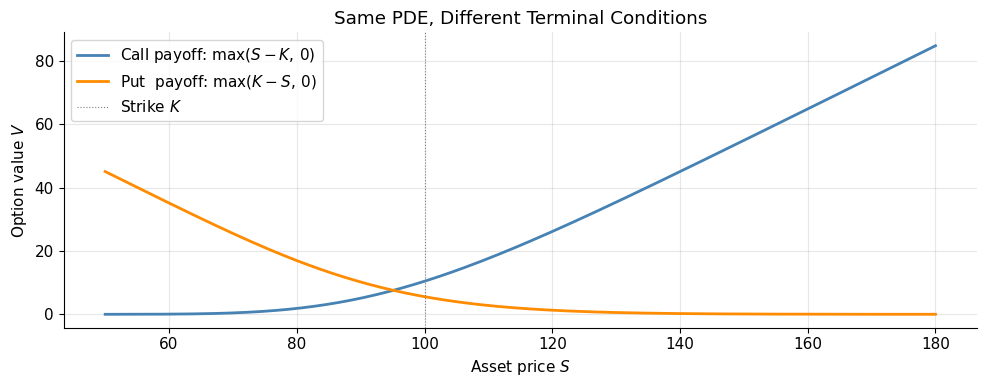

Put-call parity check: C - P = S - K*exp(-rT)
  Sample at S=100:  LHS = 20.203691  |  RHS = 20.203691
  Sample at S=120:  LHS = 46.334344  |  RHS = 46.334344
  Max error across all strikes: 2.84e-14  (machine precision — parity holds exactly)


In [14]:
def bs_put(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

tau = 1.0
call_prices = [bs_call(s, K_pde, r_pde, sigma_pde, tau) for s in S_grid]
put_prices  = [bs_put(s,  K_pde, r_pde, sigma_pde, tau) for s in S_grid]

plt.figure()
plt.plot(S_grid, call_prices, color='steelblue',  lw=2, label=r'Call payoff: $\max(S-K,\,0)$')
plt.plot(S_grid, put_prices,  color='darkorange',  lw=2, label=r'Put  payoff: $\max(K-S,\,0)$')
plt.axvline(K_pde, color='grey', lw=0.8, ls=':', label='Strike $K$')
plt.title('Same PDE, Different Terminal Conditions')
plt.xlabel('Asset price $S$')
plt.ylabel('Option value $V$')
plt.legend()
plt.tight_layout()
plt.show()

# Put-call parity: C - P = S - K*exp(-rT)
parity_lhs = np.array(call_prices) - np.array(put_prices)
parity_rhs = S_grid - K_pde * np.exp(-r_pde * tau)
error      = np.abs(parity_lhs - parity_rhs)

print(f"Put-call parity check: C - P = S - K*exp(-rT)")
print(f"  Sample at S=100:  LHS = {parity_lhs[100]:.6f}  |  RHS = {parity_rhs[100]:.6f}")
print(f"  Sample at S=120:  LHS = {parity_lhs[140]:.6f}  |  RHS = {parity_rhs[140]:.6f}")
print(f"  Max error across all strikes: {error.max():.2e}  (machine precision — parity holds exactly)")
